In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
from comparison import tests, ORDER
import pandas as pd
import numpy as np

In [3]:
arguments_list = []

for dataset_name in ['graph7c', 'ge10c']:
    for features in [("moltop",), ("moltop","ltp"), ("moltop", "ldp"), ("moltop", "ltp", "ldp")]:
        features = np.array(features)
        arguments_list.append(dict(dataset_name=dataset_name,
                                    features=features,))

In [5]:
tests(arguments_list)

test with {'features': ['ari', 'edge_betweenness', 'scan'], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'jaccard_index', 'lds', 'scan'], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'ldp_degree', 'ldp_max', 'ldp_mean', 'ldp_min', 'ldp_std', 'scan'], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'jaccard_index', 'ldp_degree', 'ldp_max', 'ldp_mean', 'ldp_min', 'ldp_std', 'lds', 'scan'], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'scan'], 'dataset_name': 'ge10c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'jaccard_index', 'lds', 'scan'], 'dataset_name': 'ge10c'} parameters existed, skipped
test with {'features': ['ari', 'edge_betweenness', 'ldp_degree', 'ldp_max', 'ldp_mean', 'ldp_min', 'ldp_std', 'scan'], 'data

In [6]:
test_data = pd.read_parquet('processed_datasets/table.parquet')
test_data['count'] = test_data['result'].apply(len)

In [7]:
test_data

,features,dataset_name,result,count
0,"[ari, edge_betweenness, scan]",graph7c,[-1],1
0,"[ari, edge_betweenness, jaccard_index, lds, scan]",graph7c,[-1],1
0,"[ari, edge_betweenness, ldp_degree, ldp_max, l...",graph7c,[-1],1
0,"[ari, edge_betweenness, jaccard_index, ldp_deg...",graph7c,[-1],1
0,"[ari, edge_betweenness, scan]",ge10c,"[840, 843, 1040, 1100, 1591, 1594, 1702, 1726,...",206
0,"[ari, edge_betweenness, jaccard_index, lds, scan]",ge10c,"[840, 843, 1040, 1100, 1702, 1726, 1718, 1728,...",124
0,"[ari, edge_betweenness, ldp_degree, ldp_max, l...",ge10c,"[2215, 2254, 2227, 2263, 2280, 2286, 2267, 228...",18
0,"[ari, edge_betweenness, jaccard_index, ldp_deg...",ge10c,"[2280, 2286, 2293, 2306, 2295, 2309]",6


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count'], dtype='object')

c:\Users\Przemek\Documents\Studia\8_semestr\PP\Graph-Isomorphism\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


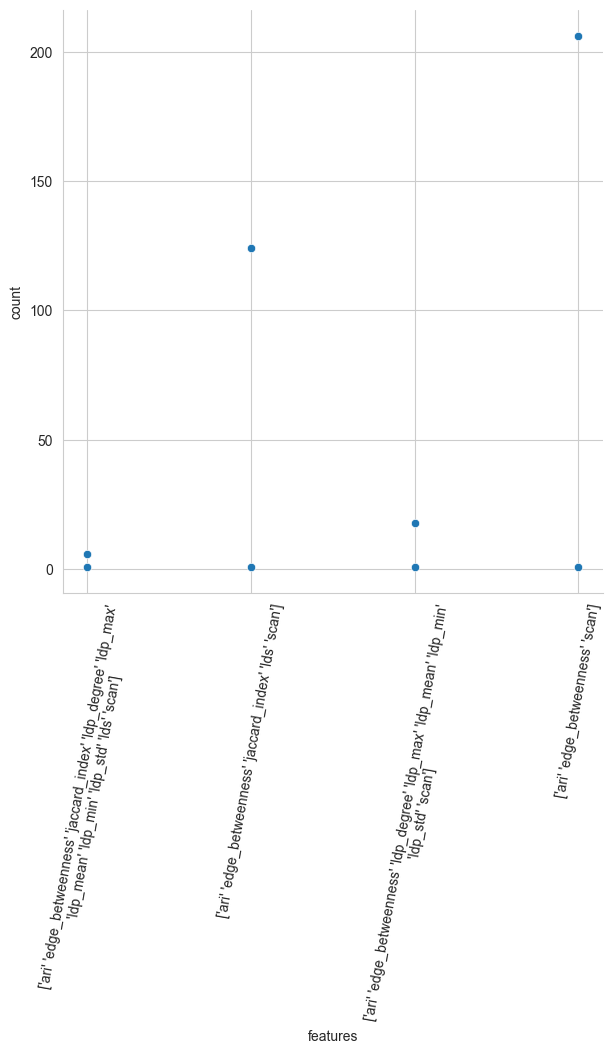

In [13]:
g = sns.pairplot(test_data.drop(columns=['result']), 
             y_vars=['count'],
             x_vars=['features'],
             )
fig = plt.gcf()
fig.set_size_inches(8,8)

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(80)

